In [21]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import scipy.stats as stats

# Custom helper functions
from helpers import timestamp_to_unix_seconds as unix_seconds # Timestamps to Unix Seconds
from helpers import timestamp_to_unix_milliseconds as unix_milliseconds # Timestamps to Unix Milliseconds

_FREQUENCY_BANDS = ['Theta','Alpha','Beta','Gamma']
_ELECTRODES = ['AF7','AF8']
_FREQUENCY_COLORS = ['red', 'blue', 'green', 'orange']

_STATIC_OBJECTS = [
    'NorthSidewalk', 'SouthSidewalk',
    'NorthWalkingPole', 'NorthDiagonalPole', 'NorthWalkingSignal', 'NorthCarSignal',
    'SouthWalkingPole', 'SouthDiagonalPole', 'SouthWalkingSignal', 'SouthCarSignal',
    'RoadEast', 'RoadWest', 'RoadCrosswalk',
    'NE_Tree_10', 'NE_Tree_30', 'NE_Tree_50',
    'NW_Tree_10', 'NW_Tree_30', 'NW_Tree_50',
    'SE_Tree_10', 'SE_Tree_30', 'SE_Tree_50',
    'SW_Tree_10', 'SW_Tree_30', 'SW_Tree_50']
_DYNAMIC_OBJECTS = [
    'Car1-Detailed', 'Car2-Detailed', 'Car3-Detailed', 'Car4-Detailed', 'Car5-Detailed',
    'Sedan1-Detailed', 'Sedan2-Detailed', 'Sedan3-Detailed', 'Sedan4-Detailed', 'Sedan5-Detailed',
    'Jeep2-Detailed', 'Jeep3-Detailed', 'Jeep4-Detailed', 'Jeep5-Detailed',
    'SportCar1-Detailed', 'SportCar2-Detailed', 'SportCar3-Detailed', 'SportCar4-Detailed', 'SportCar5-Detailed',
    'MicroBus1-Detailed', 'MicroBus2-Detailed', 'MicroBus3-Detailed', 'MicroBus4-Detailed', 'MicroBus5-Detailed',
    'Truck1-Detailed',
    'HighMale2', 'LowMale2', 'HighFemale2', 'LowFemale2']

# Synopsis

In this preliminary report, we want to form correlations between EEG patterns and certain features of interest. These pieces of interest are:

1. EEG vs Gaze target - During moments of gaze, what are corresponding EEG powers that we notice? Are there any specific EEG frequency bands that correlate strongly with gaze targets? Or perhaps, are there any correlations between EEG band power and the identified objects of interest?
2. EEG vs onset of movement attempt - Right when a person decides to navigate across the road, what EEG powers do we identify as correlated, if possible?
3. EEG vs Proxemics - when a vehicle enters the local area of a person, what correlation can we form there?

The issue with all of this is spatial autocorrelation. In short, spatial autocorrelation (and also temporal correlation) is related to the idea from "Everything is related to everything else, but near things are more related than distant things." [[Tobler, 1970]](https://doi.org/10.2307/143141). Consider something like points along a map, and you're measuring something like elevation. Points on a mountain that are closer to each other will correlate more strongly than those in the valley, simply because they're both on a mountain. This makes  some intuitive sense - the elevation at two neighboring points is extremely likely to be similar, as is the precipitation, temperature, vegetation, and fauna. These are variables whose values depend on your position on the map (though realistically you'll also encounter other factors, but for now let's go with this example).

Consider something from urban science, to be specific: house prices. You'll often see that house prices can be somewhat similar in specific regions (AKA there's a positive spatial correlation - similar things will be close to each other). But in reality, we know that this goes beyond just being in the same area - there's other factors to consider, such as the presence of school zones, public facilities, median income, and house availability. In this [online blog post](https://cran.r-project.org/web/packages/waywiser/vignettes/residual-autocorrelation.html), they mention that you'll often find spatial autocorrelations in a variable as dependent on other variables, which may or may not be spatially autocorrelated themselves. This is why if you do any spatial autocorrelation analysis, then you must also look for spatial autocorrelation in the residuals your model produces. If you see large spatial autocorrelations in the residuals, this suggests that there's something you're not considering in your model. 

Let's bring it back to the EEG case. If we look at the whole simulation from a spatial context, sure we may be able to see strong or weak EEG signals while you're looking around on the sidewalk. We may even find some correlations - i.e. we see strong theta powers that would correlate with the presence of vehicles. However, Paul doesn't really seem too enthusiastic about any multivariate correlation analysis between EEG and something like distance, mostly because of spatial autocorrelation. I think what Paul is trying to say is that any correlations we see in the data may be biased due to spatial autocorrelation. There are two ways I can possibly parse this - maybe he's saying that EEG signal behavior in one location may not be the same in another location, or that the EEG signal in response to objects in certain distances away will invariably change once we reposition ourselves. Imagine if we notice that an object is 5m away. While we're on either sidewalk, we see a strong Theta power. This MAY suggest correlation between distance of objects and Theta. However, what if we notice that we're on the crosswalk on the road and the same object at the same distance does NOT produce the same Theta activity? The residuals here therefore are important - we may see spatial autocorrelation in the differences of how our prediction model (that we'll see strong Theta activity when an object is 5m or closer) behaves in comparison with test data (i.e. we see little prediction differences when a person is on the sidewalk but big differences when they're on the crosswalk - hence a spatial autocorrelation in the residuals. Spatial autocorrelation also is optimal for static positions - the dynamic conditions we're experience such as moving cars and visual stimuli will not work well with spatial autocorrelation analysis.

This puts us in a bit of a tizzy. Does that mean that ANY EEG analysis is bogus, simply because of spatial autocorrelation? I cannot believe this to be the case - it's simply too ridiculous. That would mean that in any dynamic scenario, any and all phenomena may be spatially autocorrelated.

This kind of begs for an EEG analysis that doesn't rely on spatial data. It could be something like gaze target - i.e. I see strong Theta signals when I'm looking at a vehicle or traffic signal as opposed to when I'm looking at the pedestrian signal. But yet again, I must question whether spatial autocorrelation is also present here. Perhaps we can remove the spatial autocorrelation issue by restricting our analysis in two ways:

1. We ONLY consider when the person is static and waiting at the crosswalk. Once we identify moments when a person is truly static and waiting along at a crosswalk, then we can safely argue "fuck the spatial autocorrelation, we're looking at only moments when a person is actively waiting".
2. We only look at events specifically, i.e. when a person first focuses on a vehicle, or a traffic signal, or begins the onset of a crossing gesture.

The first one makes sense - we don't want to pollute our analysis by considering moments when a person is waiting (which is one physiological state) and when a person is walking (a separate physiological state). We lose a TON of data in this point, but we're focused on the status of waiting in most cases - while one is waiting for a moment to cross. The second one is fine, but it cannot be done without considering the first point. I once again emphasize the issue of spatial autocorrelation here - maybe your focus state is different when you are waiting vs walking, and maybe there's some autocorrelation going on during movement. 

Can we consider something like visual field or saliency? I dunno. The issue once again is dynamism in the person's behavior. Do you look at the same things all the time with the same mental acuity and focus? Not always - it's always dependent on context (i.e. if you're already in the moment of walking, then you're probably already in a different mental state).

## What did Paul Do?

Oh mighty Paul, what did you do in YOUR analysis in [your EEG paper](https://www.sciencedirect.com/science/article/pii/S0198971522001673)? Here's a snippet:

> For experiment 1, we recorded EEG data during user participation. The brain wave data for each participant are shown in Fig. 18. With the exception of Participants 1 and 2, brainwave activity dropped qualitatively across all bands during the period in which they were hit by cars (shown in pink blocks in Fig. 18). Some general commonalities were observed. Data for nine participants exhibited a very marked and sudden drop in the frequency of gamma waves (shown in orange in Fig. 18). (Gamma bands did drop for Participant 1, but toward the last few instances of the crash.)

> The results, although cursory, reveal some relevant findings. First, they demonstrate that each participant had a unique experience in the simulation, with individualized brain response to the experiments. Second, the brainwave data, across all bands, indicated that participants were generally alert and focused during the experiments. Gamma-bands correspond to the highest frequency waves in the brain, and they are associated with intense focus and concentration involved in perception (Meador, Ray, Echauz, Loring, & Vachtsevanos, 2002). Third, the sudden drop in gamma waves was associated with collision with a car, but was generally preceded by a steady decline before collision (for participants 1–7 and 10). This suggests that participants lost focus ahead of the collision. A drop in gamma signal is indicative of a quick shift from concentration to loss of focus and a decline in perceptual awareness.

Paul's focus was specifically on events - specifically, crashes. I guess that's a very specific event that occurs in very specific circumstances. This follows the 2nd point - about how you isolate to events only.

In this case, the problem would be "... what events?". I can think of some kinds of events:

* Onset of crossing attempt
* Gaze focus target while waiting

Technically, ANYthing can become an event. You usually need some rule-based system to distinguish between events and non-events though.

## What did Paul say in his emails?

This is a direct transcript between myself and Paul in an email exchange:

> Paul: Damien was saying he was going to run a multivariate correlation with distance to other pedestrians, I explained that you can't do this because distance is always autocorrelated (it's correlated with itself). He would need to run a spatially-adjusted regression which is more trouble than it is worth as it's basically a dummy variable version of the distance weight so you end up with results that are valid but usually meaningless.

> Me: In this case, do you think it would be noteworthy to run LISA with visual saliency of certain obstacles in a scene? IE attempting to correlate EEG with things that occupy the visual field of participants?

> Spatial autocorrelation is correlation of a variable with itself. So, you would just end up with statistically significant single-point instances. These can be points with surrounding values (of the same variable) that are also high (positive spatial autocorrelation), also low (also positive spatial autocorrelation). This would make sense for fixed features, but not for dynamic features.

The reason why I'm really not sure about this entire exchange is because I'm not exactly sure if Paul got what we were attempting to do. Either that or Damien just really badly explained everything. I think it's a combo of both, knowing their communication skills (or lack thereof).

Let's consider a spatial perspective. Let's look at something like distance, and then map them on some 2D map of the virtual world. If we consider this, then we're looking at EEG with respect to distant objects. Technically this does become a spatial thing - we can treat objects in the 2D space as nodes, and then the connection between your own position (which itself is a node) and that other node is quantized in two ways: EEG signal, and Euclidean distance. Does this create an issue of autocorrelation? Not sure. This is because in a spatial autocorrelation, using something like Moran's I, we look at locations and values at those locations. Correlation analysis would then attempt to see if there's a pattern within the spatial data here. In this case, it's not really the same, because 1) we have dynamic objects, and 2) this is continuous data, despite being spatially realized in some way. But maybe there's a kernel of truth to Paul's statement on this?

What really personally irks me to no end is that I'm not exactly sure if he's responding to my original query about EEG correlations. Okay, maybe he is to an extent if we view the visual field as a "map" and then we attribute gaze fixation points (relative to the screen) with EEG values. That MAY correspond to spatial autocorrelation to an extent...


## Is EEG an autocorrelated data?

When you kind of think about it, autocorrelation implies that "the past stays with us" - AKA past events will lead into present events, and then hence lead to future events. This is why autocorrelation inspects the correlation between data and a time-lagged version of itself. If this is the case, then is EEG always going to be autocorrelated? We have to acknowledge that data points in EEG data will not really be independent because we know that the past EEG status may affect the current EEG status. 

## Is that really it?

I'm not convinced. There must be SOMETHING we can do to rationalize correlations. Let's really say that we restrict our analysis to waiting - the act of waiting. Okay, this prevents spatial autocorrelation in reference to the user's position in the world. That should be fine. The issue however, is ANYTHING related to proxemics, space, or visual field. ANYTHING that suggests spatial distribution cannot be conducted with EEG - so we can't look at proxemics. Fucking sucks. Okay, then we'll have to fall back on one of the most uncomfortable issues I have to deal with: events.

We need a rule-based system to convert the continuous data we're gathering with events. This concerns what events we are specifically looking at here. I'll reiterate the events we want to look at.

1. Onset of gaze target type (vehicle, traffic signal, pedestrian signal, background pedestrian)
2. Onset of crossing attempt

Doing ANYTHING related to spatial distribution or proxemics leads to autocorrelation. This is the only compromise I can think of. 

## Trial Preprocessing

In [2]:
# MUST BE MANUALLY DEFINED
_PARTICIPANT_DIR = '../samples/P1/'

# Read Trials
trial_df = pd.read_csv(os.path.join(_PARTICIPANT_DIR, 'trials.csv'))

# Get the initial endings, so that we can filter out some EEG data
_INITIAL_END_FRAME = trial_df.loc[0,'end_frame']
_INITIAL_END_TIMESTAMP = trial_df.loc[0,'end_timestamp']
_INITIAL_END_UNIX = trial_df.loc[0,'end_unix']
_TRIAL_END_UNIX = trial_df.loc[8,'end_unix']

display(trial_df)
print("Ending Frame, Timestamp, and Unix Milliseconds:", _INITIAL_END_FRAME, _INITIAL_END_TIMESTAMP, _INITIAL_END_UNIX)
print("Trial End Unix Milliseconds", _TRIAL_END_UNIX)

,trial_number,car_congestion,start_unix,start_timestamp,start_frame,end_unix,end_timestamp,end_frame
0,0,NoCongestion,1742844904966,3.656917,263,1742844921602,20.01333,939
1,1,MinimalCongestion,1742844921605,20.013330,939,1742844939478,37.90667,2049
2,2,NoCongestion,1742844939478,37.906670,2049,1742844978617,77.01334,3953
3,3,MinimalCongestion,1742844978617,77.013340,3953,1742845018134,116.56000,6365
4,4,MinimalCongestion,1742845018135,116.560000,6365,1742845032997,131.40000,7051
5,5,NoCongestion,1742845032997,131.400000,7051,1742845049913,148.33330,8103
6,6,NoCongestion,1742845049914,148.333300,8103,1742845066703,165.10670,8878
7,7,MinimalCongestion,1742845066703,165.106700,8878,1742845077660,176.09330,9571
8,8,NoCongestion,1742845077660,176.093300,9571,1742845089786,188.18670,10150


Ending Frame, Timestamp, and Unix Milliseconds: 939 20.01333 1742844921602
Trial End Unix Milliseconds 1742845089786


## EEG Pre-Processing

_Normalize EEG responses by looking at the rest state EEG and normalizing each EEG band to a range of 0-1. This is done by calculating the min and max of the EEG rest states for each band and then normalizing._

In [3]:
def LoadEEGCSV(src_filepath:str, drop_raw:bool=True, drop_accel:bool=True, drop_gyro:bool=True):
    df = pd.read_csv(src_filepath)
    df = df[~df['TimeStamp'].isna()] # Remove rows where timestamp is na
    df = df[~df['Battery'].isna()]   # Remove battery rows - useless
    df['unix_ms'] = df['TimeStamp'].apply(lambda x: int(unix_milliseconds(x))) # Convert from timestamp to unix ms
    
    drop_list = ['TimeStamp', 'Elements', 'Battery', 'HeadBandOn','AUX_RIGHT','AUX_LEFT','HSI_TP9','HSI_AF7','HSI_AF8','HSI_TP10']
    if drop_raw: drop_list.extend(['RAW_AF7','RAW_AF8','RAW_TP9','RAW_TP10'])
    if drop_accel: drop_list.extend(['Accelerometer_X','Accelerometer_Y','Accelerometer_Z'])
    if drop_gyro: drop_list.extend(['Gyro_X','Gyro_Y','Gyro_Z'])
    df.drop(columns=drop_list, inplace=True) # Drop useless columns
    
    # For each frequency, exit from log to actual power, then remove the older column
    for freq in _FREQUENCY_BANDS:
        for electrode in _ELECTRODES:
            in_colname = f'{freq}_{electrode}'
            out_colname = f'{in_colname}_Pow'
            df[out_colname] = 10 ** df[in_colname]
            df.drop(columns=[in_colname], inplace=True)
            df.rename(columns={out_colname:in_colname},inplace=True)
    
    return df

def GetRange(col):
    return (col.min(), col.max())

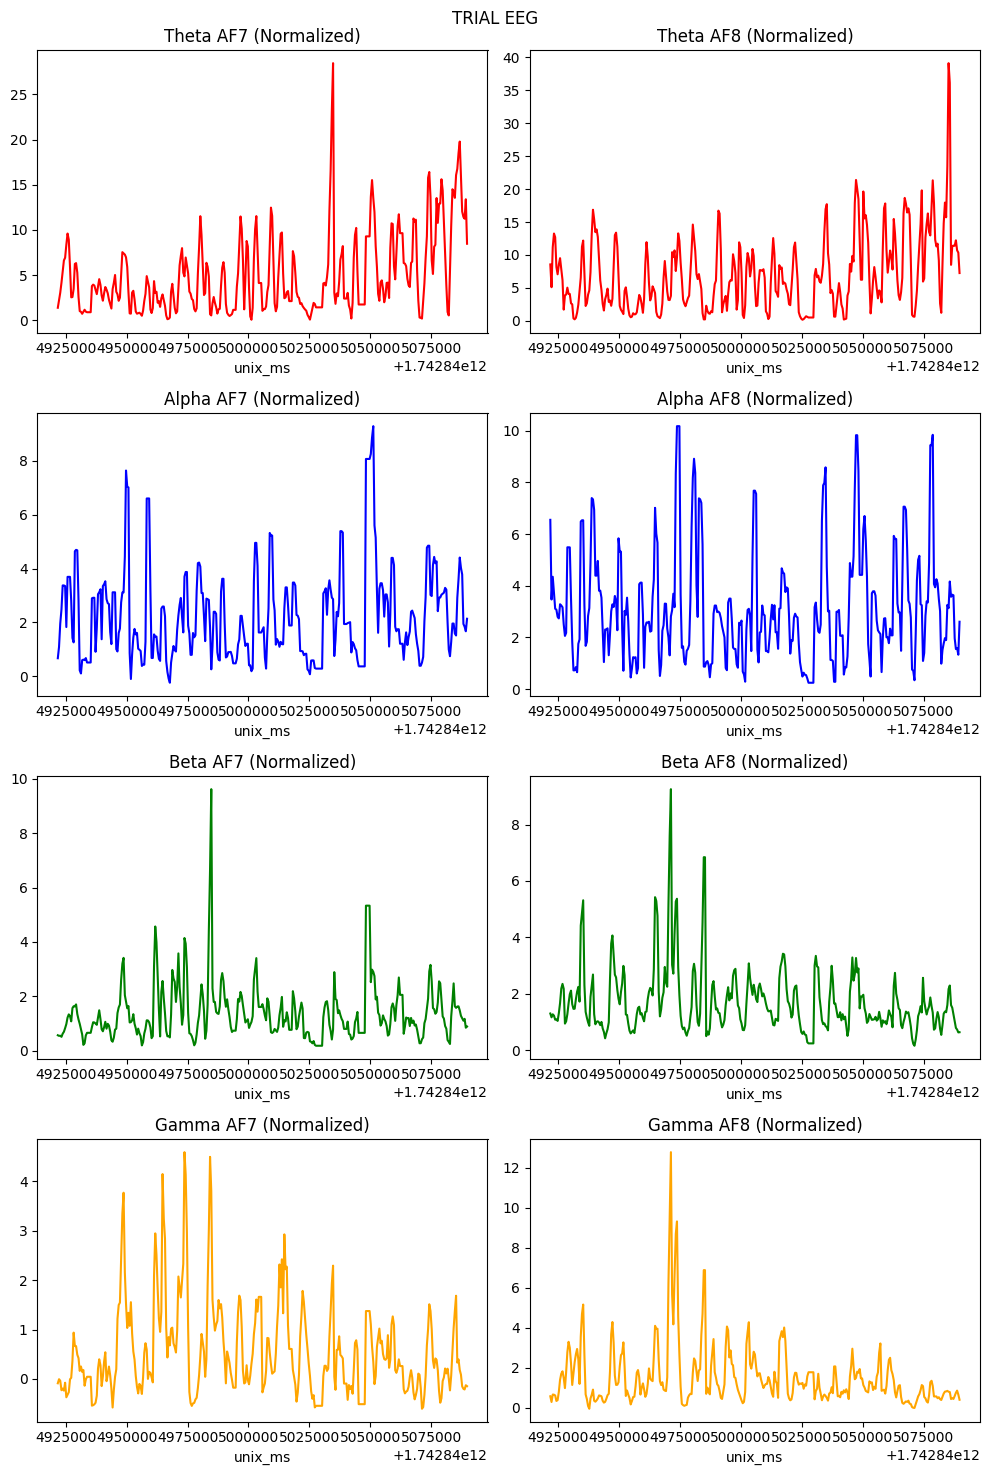

In [4]:
rest_df = LoadEEGCSV(os.path.join(_PARTICIPANT_DIR, 'eeg_rest.csv')) # First load EEG, with basic filtering steps
rest_df['rel_unix_ms'] = rest_df['unix_ms'] - rest_df['unix_ms'].iloc[0] # Get relative unix ms for easier filtering
rest_df = rest_df[(rest_df['rel_unix_ms']>=10000) & (rest_df['rel_unix_ms']<=40000)]

eeg_df = LoadEEGCSV(os.path.join(_PARTICIPANT_DIR, 'eeg_vr.csv'))
eeg_df = eeg_df[eeg_df['unix_ms'].between(_INITIAL_END_UNIX,_TRIAL_END_UNIX)]

# Look through each frequency-electrode combo, generate normalized version
for freq in _FREQUENCY_BANDS:
    for electrode in _ELECTRODES:
        in_colname = f'{freq}_{electrode}'
        out_colname = f'{in_colname}_normalized'
        (colmin, colmax) = GetRange(rest_df[in_colname])
        eeg_df[out_colname] = (eeg_df[in_colname] - colmin) / (colmax - colmin)
        
# Let's display this participant's EEG data
fig, ax = plt.subplots(nrows=len(_FREQUENCY_BANDS), ncols=len(_ELECTRODES))
fig.set_figheight(15)
fig.set_figwidth(10)
fig.suptitle(f"TRIAL EEG")

for i in range(len(_FREQUENCY_BANDS)):
    color = _FREQUENCY_COLORS[i]
    freq = _FREQUENCY_BANDS[i]
    for j in range(len(_ELECTRODES)):
        electrode = _ELECTRODES[j]
        colname = f"{freq}_{electrode}_normalized"
        title = f"{freq} {electrode} (Normalized)"
        this_trial_ax = eeg_df.plot.line(x='unix_ms',y=colname, ax=ax[i,j], color=color, title=title)
        this_trial_ax.legend_ = None

plt.tight_layout()
#plt_savename = os.path.join(trial_dir, f'eeg_{trial_filename}.png')
#plt.savefig(plt_savename, bbox_inches="tight", pad_inches=0.1,)
plt.show()

## Identifying Events

_Alongside `eeg_vr.csv`, we also have `eye.csv`, `positions.csv`, and `trials.csv`. Among these:_

* _`eye.csv` = the raw gaze tracking data from Unity during simulation_
* _`positions.csv` = the positions of all active entities in the scene during simulation. All positions and forward directions are relative to world space._
* _`trials.csv` = the timings (beginning and endings) for each trial during simulation._

_Recall we want to look at these specific events:_

* _**Onset of gaze target fixation label & fixation**: Self-explanatory, just identify moments when gaze fixation hits targets. Unique to each target label, which is provided alongside eye data._
* _**Onset of crossing**: We know that a person begins to attempt crossing the moment that 1) their velocity increases, and 2) their position in world space exists between a range of `2.25m` and `7.75m` along the Z-axis (the road is 5.5m long, the road center is at `5m` in world space)._

### Crossing Onset Events

_This involves the following steps:_

1. _Calculating their velocity (speed would be sufficient) along the XZ axis_
2. _Grouping rows based on whether their velocity is bigger than some threshold (let's say `1m/sec`) and that their Z position is between `2.25` and `7.75`._

In [5]:
positions_df = pd.read_csv(os.path.join(_PARTICIPANT_DIR, 'positions.csv'))
positions_df['frame'] = positions_df['frame'].astype('Int64')
display(positions_df)

player_df = positions_df[(positions_df['obj_name']=='CenterEyeAnchor') & (positions_df['frame'] >= _INITIAL_END_FRAME)] # Get only player position
player_df['frame'] = player_df['frame'].astype('Int64')

# Calculate time difference
player_df['time_diff'] = player_df['unix_ms'].diff() / 1000 # unix ms to sec
player_df['displacement'] = np.sqrt((player_df['pos_x'].diff()**2) + (player_df['pos_z'].diff()**2))
player_df['speed'] = player_df['displacement'] / player_df['time_diff']

,unix_ms,rel_timestamp,frame,obj_name,guid,pos_x,pos_y,pos_z,forward_x,forward_y,forward_z
0,1742844905014,3.656917,263,HighMale2,29686,24.070000,0.025000,-3.400000,0.082211,0.000000,9.966149e-01
1,1742844905014,3.656917,263,CenterEyeAnchor,27386,0.021203,1.708971,0.081914,-0.098991,-0.045232,9.940597e-01
2,1742844905014,3.656917,263,LowFemale2,33854,17.210000,0.025000,11.370000,0.000000,0.000000,1.000000e+00
3,1742844905014,3.656917,263,HighFemale2,33816,-16.420000,0.025000,-2.430000,0.000000,0.000000,1.000000e+00
4,1742844905014,3.656917,263,LowMale2,28708,-26.460000,0.025000,13.550000,0.000000,0.000000,1.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...
89210,1742845089761,188.181900,10149,LowFemale2,33854,-25.186230,0.025000,11.289810,1.000000,0.000000,8.133054e-04
89211,1742845089761,188.181900,10149,HighFemale2,33816,-47.322460,0.025000,-1.307108,-0.998781,0.000000,-4.937160e-02
89212,1742845089761,188.181900,10149,LowMale2,28708,26.247540,0.025000,12.806580,-0.999892,0.000000,-1.470745e-02
89213,1742845089761,188.181900,10149,MicroBus3-Detailed,27684,-35.334090,0.000000,3.750000,1.000000,0.000000,-1.192093e-07


C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_28440\804903256.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  player_df['frame'] = player_df['frame'].astype('Int64')
C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_28440\804903256.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  player_df['time_diff'] = player_df['unix_ms'].diff() / 1000 # unix ms to sec
C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_28440\804903256.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from 

C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_28440\4003896034.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  moving_df['next_frame'] = moving_df['frame'].shift(-1)
C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_28440\4003896034.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  moving_df['frame_diff'] = moving_df['next_frame'] - moving_df['frame']
C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_28440\4003896034.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

,start_unix_ms,start_frame,start_rel_sec,end_unix_ms,end_frame,end_rel_sec,group
group,,,,,,,
0,1742844921610,939,20.02772,1742844921744,944,20.16359,0
1,1742844935555,1770,33.98650,1742844939675,2063,38.10878,1
2,1742844974330,3790,72.76270,1742844978788,3959,77.20721,2
3,1742845013522,6066,111.94830,1742845018321,6375,116.75120,3
4,1742845029334,6906,127.76430,1742845033141,7056,131.56030,4
5,1742845047046,7910,145.47710,1742845050041,8112,148.47260,5
6,1742845062655,8730,161.08390,1742845066846,8883,165.26610,6
7,1742845074196,9340,172.62670,1742845077770,9578,176.20140,7
8,1742845085835,9986,184.26140,1742845089734,10148,188.15340,8


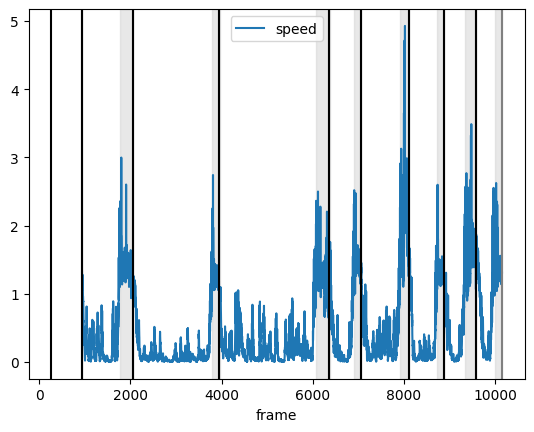

In [6]:
moving_df = player_df[player_df['pos_z'].between(2.25, 7.75)]
moving_df['next_frame'] = moving_df['frame'].shift(-1)
moving_df['frame_diff'] = moving_df['next_frame'] - moving_df['frame']
moving_df['group'] = (moving_df['next_frame'] != moving_df['frame'] + 1).cumsum()
moving_df = moving_df[moving_df['frame_diff']==1]

crossing_df = moving_df.groupby('group').agg(
    start_unix_ms=('unix_ms', 'first'),
    start_frame=('frame','first'),
    start_rel_sec=('rel_timestamp','first'),
    end_unix_ms=('unix_ms', 'last'),
    end_frame=('frame','last'),
    end_rel_sec=('rel_timestamp','last'),
    group=('group','first')
)

speed_ax = player_df.plot.line(x='frame',y='speed')
for index, row in trial_df.iterrows():
    speed_ax.axvline(x=row['start_frame'], color='black')
    speed_ax.axvline(x=row['end_frame'], color='gray')
    
for index, row in crossing_df.iterrows():
    plt.axvspan(row['start_frame'], row['end_frame'], color='lightgray', alpha=0.5)
    
display(crossing_df)

### Eye Events

_This is a two-step process:_

1. _Given the raw rows, simply condense by groups of adjacent rows with the same gaze target._
2. _Filter based on gaze length (gazes must be longer than 0.25sec). Subsequent groups that have the same target whose split is smaller than 0.5s are considered the same group (i.e. this would account for accidental breaks in gaze fixation)._

_An additional issue: there may be the issue that the gaze tracking will hit anything outside the active area. To fix this, we need to correlate the world positions of each gazed_upon item in the world. If the position of it is outside the active space, or if it's not even present in the positions df at the indicated timestamp, then we filter it out._

In [69]:
eye_df = pd.read_csv(os.path.join(_PARTICIPANT_DIR, 'eye.csv'))
eye_df = eye_df[eye_df['side']=='Left'] # Only consider left (we need this anyways during screen point conversion)
eye_df = eye_df[eye_df['unix_ms'].between(_INITIAL_END_UNIX, _TRIAL_END_UNIX)] # Only consider gazes within the trial period
eye_df['frame'] = eye_df['frame'].astype('Int64')

eye_positions_df = pd.merge(eye_df, positions_df, left_on='target_name', right_on='obj_name', how='left')
eye_positions_df = eye_positions_df[
    (eye_positions_df['target_name'].isin(_STATIC_OBJECTS)) 
    | (
        (eye_positions_df['target_name'].isin(_DYNAMIC_OBJECTS) 
        & (eye_positions_df['pos_z'].between(-13.625, 23.625)))
        & (eye_positions_df['pos_x'].between(-75, 75)))
]
eye_df = eye_positions_df.drop(columns=['unix_ms_y','rel_timestamp_y','frame_y','obj_name','pos_x','pos_y','pos_z','forward_x','forward_y','forward_z','guid'])
eye_df.rename(columns={'unix_ms_x':'unix_ms','rel_timestamp_x':'rel_timestamp','frame_x':'frame'}, inplace=True)
eye_df.drop_duplicates(subset='unix_ms', keep="first", inplace=True)

In [70]:
# Group by target name
eye_df['target_name_group'] = (eye_df['target_name'] != eye_df['target_name'].shift()).cumsum()
gazegroup_df = eye_df.groupby('target_name_group').agg(
    start_unix_ms=('unix_ms', 'first'),
    start_frame = ('frame','first'),
    end_unix_ms=('unix_ms', 'last'),
    end_frame=('frame','last'),
    target_name=('target_name', 'first')
)
gazegroup_df['duration_ms'] = gazegroup_df['end_unix_ms'] - gazegroup_df['start_unix_ms']

# Remove rows where timestamp is na
# We do this AFTER all groupings to capture moments when gaze breaks away
gazegroup_df = gazegroup_df[~gazegroup_df['target_name'].isna()]
gazegroup_df.reset_index(drop=True, inplace=True)

In [71]:
gazegroup_df['next_start_unix_ms'] = gazegroup_df['start_unix_ms'].shift(-1)
gazegroup_df['time_diff'] = gazegroup_df['next_start_unix_ms'] - gazegroup_df['end_unix_ms']
gaze_threshold = 250.0

# Create a new group column based on both the time difference and the target value
group_col = [0]  # Start with the first group
for i in range(0, len(gazegroup_df)-1):
    # Check if the time difference is within the threshold and the target is the same
    if gazegroup_df.loc[i, 'time_diff'] <= gaze_threshold and gazegroup_df.loc[i, 'target_name'] == gazegroup_df.loc[i+1 , 'target_name']:
        # If both conditions are met, group together (same group number as previous)
        group_col.append(group_col[-1])
    else:
        # Otherwise, create a new group (increment the group number)
        group_col.append(group_col[-1] + 1)

# Add the new group column to the DataFrame
gazegroup_df['group'] = group_col

# Drop the extra columns (optional)
gazegroup_df.drop(columns=['next_start_unix_ms', 'time_diff'], inplace=True)

# regroup again
gaze_df = gazegroup_df.groupby('group').agg(
    start_unix_ms=('start_unix_ms', 'first'),
    start_frame=('start_frame','first'),
    end_unix_ms=('end_unix_ms', 'last'),
    end_frame=('end_frame','last'),
    target_name=('target_name', 'first')
)
gaze_df['duration_ms'] = gaze_df['end_unix_ms'] - gaze_df['start_unix_ms']
gaze_df.reset_index(drop=True, inplace=True)

display(gaze_df.head(20))

,start_unix_ms,start_frame,end_unix_ms,end_frame,target_name,duration_ms
0,1742844921609,939,1742844922895,986,NorthSidewalk,1286
1,1742844922929,988,1742844922929,988,NorthWalkingPole,0
2,1742844922946,989,1742844922990,992,NorthSidewalk,44
3,1742844923020,994,1742844923020,994,RoadWest,0
4,1742844923049,996,1742844923049,996,NorthSidewalk,0
5,1742844923077,998,1742844923164,1004,RoadWest,87
6,1742844923193,1006,1742844923311,1014,SouthSidewalk,118
7,1742844923400,1020,1742844923491,1026,SW_Tree_10,91
8,1742844924032,1062,1742844924597,1094,MicroBus1-Detailed,565
9,1742844924791,1106,1742844924961,1117,SouthSidewalk,170


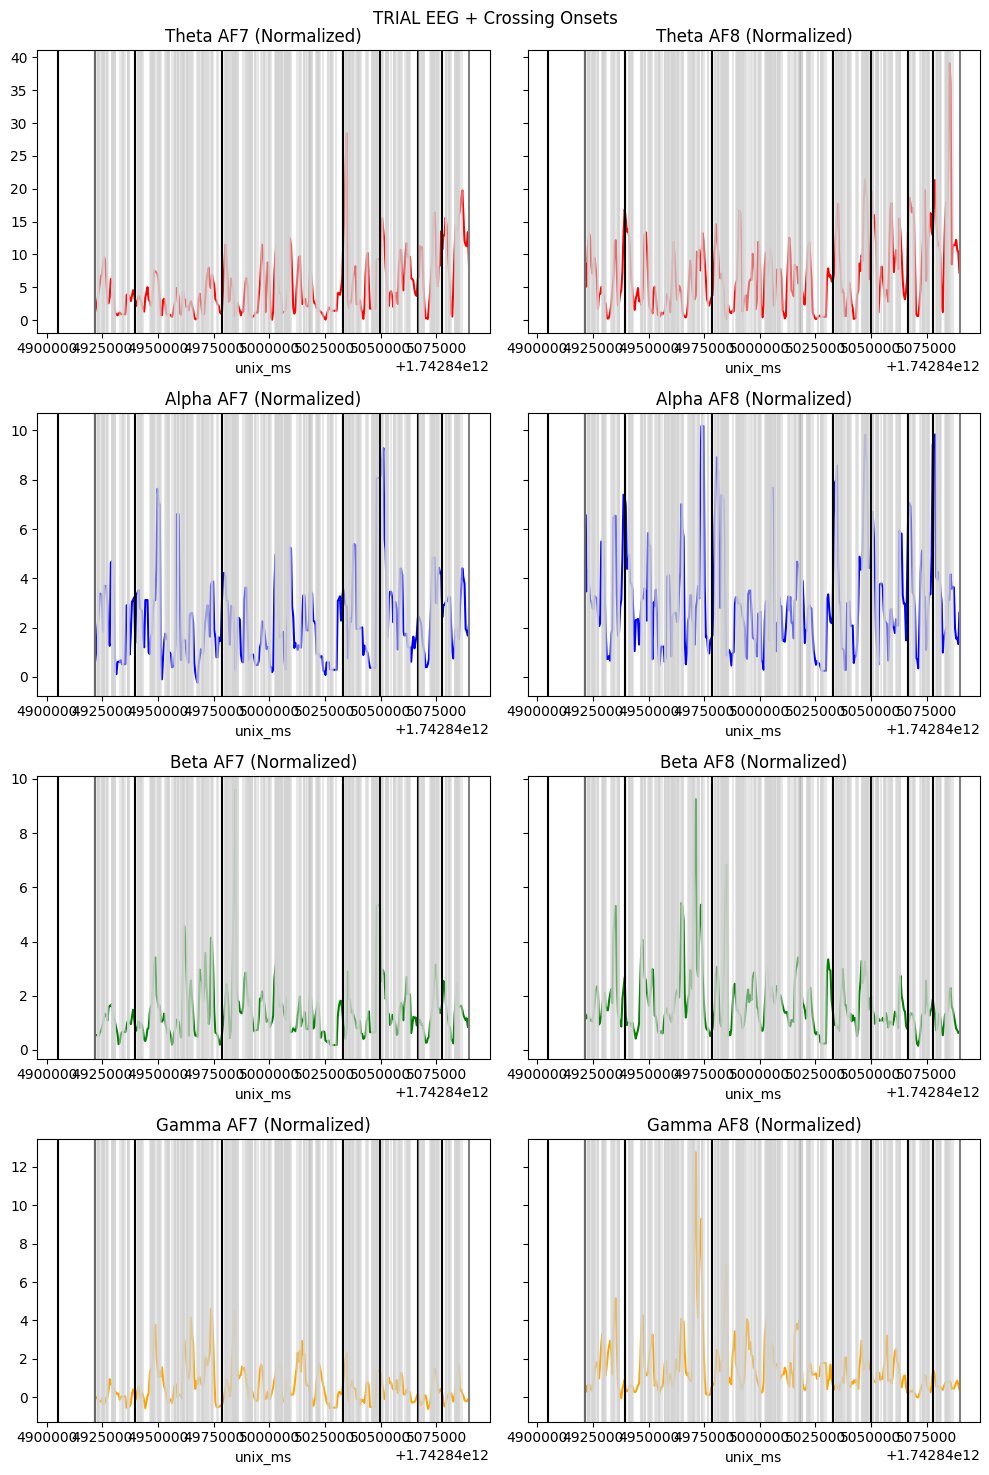

In [49]:
# Let's display this participant's EEG data
fig, ax = plt.subplots(nrows=len(_FREQUENCY_BANDS), ncols=len(_ELECTRODES), sharey='row')
fig.set_figheight(15)
fig.set_figwidth(10)
fig.suptitle(f"TRIAL EEG + Crossing Onsets")

for i in range(len(_FREQUENCY_BANDS)):
    color = _FREQUENCY_COLORS[i]
    freq = _FREQUENCY_BANDS[i]
    for j in range(len(_ELECTRODES)):
        electrode = _ELECTRODES[j]
        colname = f"{freq}_{electrode}_normalized"
        title = f"{freq} {electrode} (Normalized)"
        this_ax = eeg_df.plot.line(x='unix_ms',y=colname, ax=ax[i,j], color=color, title=title)
        this_ax.legend_ = None
        for index, row in trial_df.iterrows():
            this_ax.axvline(x=row['start_unix'], color='black')
            this_ax.axvline(x=row['end_unix'], color='gray')
        for index, row in gaze_df.iterrows():
            this_ax.axvline(x=row['start_unix_ms'], color='lightgray', alpha=0.5)

plt.tight_layout()
plt.show()

## Correlating EEG and Events

_The idea is that, upon the onset of a specific event start, we should look at the EEG signal and determine the following:_

* _Is the EEG data actually useful? IE it's not creating flatlines._
* _Assuming the data is usable, look at 3 specific windows: prediction (up to 2sec before the onset), onset (from -1sec to 1sec relative to onset), and detection (up to 2sec after onset)._
* _For either prediction/onset/detection, get the average EEG signal power for each frequency-electrode combo within that window. Aggregate all averages into a combined list._

_The correlation analysis considers the frequency-band combo vs onset. The idea is that we want to check if the frequency-electrode combo correlates with onset cues on the basis of avg. EEG power._

_One additional consideration is the gaze target, which adds an additional layer of features._

### EEG vs Gaze Target

_Complicated. We need to consider whether the object type corresponds to EEG frequency bands and/or electrodes._
_Several axes we can explore. Namely, whether the gaze target is a dynamic or static object, and the specific category that the gaze target is associated as._

In [72]:
_OBJECT_TYPE_DICT = {
    'NorthSidewalk':'Sidewalk',
    'SouthSidewalk':'Sidewalk',
    'RoadEast':'Road',
    'RoadWest':'Road',
    'RoadCrosswalk':'Road',
    'NorthWalkingPole':'SignalPole',
    'NorthDiagonalPole':'SignalPole',
    'SouthWalkingPole':'SignalPole',
    'SouthDiagonalPole':'SignalPole',
    'NorthWalkingSignal':'PedestrianSignal',
    'SouthWalkingSignal':'PedestrianSignal',
    'NorthCarSignal':'VehicleSignal',
    'SouthCarSignal':'VehicleSignal',
    'NE_Tree_10':'Tree',
    'NE_Tree_30':'Tree',
    'NE_Tree_50':'Tree',
    'NW_Tree_10':'Tree',
    'NW_Tree_30':'Tree',
    'NW_Tree_50':'Tree',
    'SE_Tree_10':'Tree',
    'SE_Tree_30':'Tree',
    'SE_Tree_50':'Tree',
    'SW_Tree_10':'Tree',
    'SW_Tree_30':'Tree',
    'SW_Tree_50':'Tree',
    'Car1-Detailed':'Vehicle',
    'Car2-Detailed':'Vehicle',
    'Car3-Detailed':'Vehicle',
    'Car4-Detailed':'Vehicle',
    'Car5-Detailed':'Vehicle',
    'Sedan1-Detailed':'Vehicle',
    'Sedan2-Detailed':'Vehicle',
    'Sedan3-Detailed':'Vehicle',
    'Sedan4-Detailed':'Vehicle',
    'Sedan5-Detailed':'Vehicle',
    'Jeep2-Detailed':'Vehicle',
    'Jeep3-Detailed':'Vehicle',
    'Jeep4-Detailed':'Vehicle',
    'Jeep5-Detailed':'Vehicle',
    'SportCar1-Detailed':'Vehicle',
    'SportCar2-Detailed':'Vehicle',
    'SportCar3-Detailed':'Vehicle',
    'SportCar4-Detailed':'Vehicle',
    'SportCar5-Detailed':'Vehicle',
    'MicroBus1-Detailed':'Vehicle',
    'MicroBus2-Detailed':'Vehicle',
    'MicroBus3-Detailed':'Vehicle',
    'MicroBus4-Detailed':'Vehicle',
    'MicroBus5-Detailed':'Vehicle',
    'Truck1-Detailed':'Vehicle',
    'HighMale2':'Pedestrian',
    'LowMale2':'Pedestrian',
    'HighFemale2':'Pedestrian',
    'LowFemale2':'Pedestrian'
}
_OBJECT_TYPE_UNIQUE = set(_OBJECT_TYPE_DICT.values())
print('Unique Types:', _OBJECT_TYPE_UNIQUE)

_OBJECT_STATE_DICT = {
    'NorthSidewalk':'Static',
    'SouthSidewalk':'Static',
    'RoadEast':'Static',
    'RoadWest':'Static',
    'RoadCrosswalk':'Static',
    'NorthWalkingPole':'Static',
    'NorthDiagonalPole':'Static',
    'SouthWalkingPole':'Static',
    'SouthDiagonalPole':'Static',
    'NorthWalkingSignal':'Static',
    'SouthWalkingSignal':'Static',
    'NorthCarSignal':'Static',
    'SouthCarSignal':'Static',
    'NE_Tree_10':'Static',
    'NE_Tree_30':'Static',
    'NE_Tree_50':'Static',
    'NW_Tree_10':'Static',
    'NW_Tree_30':'Static',
    'NW_Tree_50':'Static',
    'SE_Tree_10':'Static',
    'SE_Tree_30':'Static',
    'SE_Tree_50':'Static',
    'SW_Tree_10':'Static',
    'SW_Tree_30':'Static',
    'SW_Tree_50':'Static',
    'Car1-Detailed':'Dynamic',
    'Car2-Detailed':'Dynamic',
    'Car3-Detailed':'Dynamic',
    'Car4-Detailed':'Dynamic',
    'Car5-Detailed':'Dynamic',
    'Sedan1-Detailed':'Dynamic',
    'Sedan2-Detailed':'Dynamic',
    'Sedan3-Detailed':'Dynamic',
    'Sedan4-Detailed':'Dynamic',
    'Sedan5-Detailed':'Dynamic',
    'Jeep2-Detailed':'Dynamic',
    'Jeep3-Detailed':'Dynamic',
    'Jeep4-Detailed':'Dynamic',
    'Jeep5-Detailed':'Dynamic',
    'SportCar1-Detailed':'Dynamic',
    'SportCar2-Detailed':'Dynamic',
    'SportCar3-Detailed':'Dynamic',
    'SportCar4-Detailed':'Dynamic',
    'SportCar5-Detailed':'Dynamic',
    'MicroBus1-Detailed':'Dynamic',
    'MicroBus2-Detailed':'Dynamic',
    'MicroBus3-Detailed':'Dynamic',
    'MicroBus4-Detailed':'Dynamic',
    'MicroBus5-Detailed':'Dynamic',
    'Truck1-Detailed':'Dynamic',
    'HighMale2':'Dynamic',
    'LowMale2':'Dynamic',
    'HighFemale2':'Dynamic',
    'LowFemale2':'Dynamic'
}
_OBJECT_STATE_UNIQUE = set(_OBJECT_STATE_DICT.values())
print('Unique states:', _OBJECT_STATE_UNIQUE)

# Must return a dict with the new colnames
def GetGazeWindowEEGs(row, eeg, colnames):
    # Initialize return dict
    return_dict = {}
    # Get gaze target qualities
    return_dict['target_type'] = _OBJECT_TYPE_DICT[row['target_name']]
    return_dict['target_state'] = _OBJECT_STATE_DICT[row['target_name']]
    # For each freq_band column name, get the prior, during, and after windows
    prior = eeg[eeg['unix_ms'].between(row['start_unix_ms']-2000, row['start_unix_ms'])]
    during = eeg[eeg['unix_ms'].between(row['start_unix_ms']-1000, row['start_unix_ms']+1000)]
    after = eeg[eeg['unix_ms'].between(row['start_unix_ms'], row['start_unix_ms']+2000)]
    for col in colnames:
        return_dict[f'{col}-prior_avg'] = prior[f'{col}_normalized'].mean()
        return_dict[f'{col}-prior_max'] = prior[f'{col}_normalized'].max()
        return_dict[f'{col}-during_avg'] = during[f'{col}_normalized'].mean()
        return_dict[f'{col}-during_max'] = during[f'{col}_normalized'].max()
        return_dict[f'{col}-after_avg'] = after[f'{col}_normalized'].mean()
        return_dict[f'{col}-after_max'] = after[f'{col}_normalized'].max()
    return return_dict

Unique Types: {'VehicleSignal', 'SignalPole', 'PedestrianSignal', 'Vehicle', 'Pedestrian', 'Road', 'Tree', 'Sidewalk'}
Unique states: {'Dynamic', 'Static'}


,start_unix_ms,start_frame,end_unix_ms,end_frame,target_name,duration_ms,target_type,target_state,Theta_AF7-prior_avg,Theta_AF7-prior_max,...,Gamma_AF7-during_avg,Gamma_AF7-during_max,Gamma_AF7-after_avg,Gamma_AF7-after_max,Gamma_AF8-prior_avg,Gamma_AF8-prior_max,Gamma_AF8-during_avg,Gamma_AF8-during_max,Gamma_AF8-after_avg,Gamma_AF8-after_max
1,1742844922929,988,1742844922929,988,NorthWalkingPole,0,SignalPole,Static,2.197331,3.041973,...,-0.117611,-0.006784,-0.185502,-0.078006,0.504033,0.657135,0.550671,0.657135,0.493879,0.649761
2,1742844922946,989,1742844922990,992,NorthSidewalk,44,Sidewalk,Static,2.197331,3.041973,...,-0.117611,-0.006784,-0.185502,-0.078006,0.504033,0.657135,0.550671,0.657135,0.493879,0.649761
3,1742844923020,994,1742844923020,994,RoadWest,0,Road,Static,2.197331,3.041973,...,-0.117611,-0.006784,-0.185502,-0.078006,0.504033,0.657135,0.550671,0.657135,0.493879,0.649761
4,1742844923049,996,1742844923049,996,NorthSidewalk,0,Sidewalk,Static,2.197331,3.041973,...,-0.117611,-0.006784,-0.185502,-0.078006,0.504033,0.657135,0.550671,0.657135,0.493879,0.649761
5,1742844923077,998,1742844923164,1004,RoadWest,87,Road,Static,2.197331,3.041973,...,-0.117611,-0.006784,-0.185502,-0.078006,0.504033,0.657135,0.550671,0.657135,0.493879,0.649761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,1742845084779,9934,1742845084856,9939,SW_Tree_10,77,Tree,Static,13.177546,14.501931,...,1.104396,1.683530,0.646624,1.683530,0.791565,0.840800,0.808219,0.840800,0.622658,0.796700
354,1742845085188,9961,1742845085201,9962,LowFemale2,13,Pedestrian,Dynamic,13.177546,14.501931,...,1.104396,1.683530,0.646624,1.683530,0.791565,0.840800,0.808219,0.840800,0.622658,0.796700
355,1742845085442,9971,1742845085442,9971,NorthSidewalk,0,Sidewalk,Static,14.582561,16.071404,...,0.945845,1.683530,0.247295,0.394256,0.813996,0.840800,0.713269,0.840800,0.532329,0.782468
356,1742845085737,9981,1742845085737,9981,LowMale2,0,Pedestrian,Dynamic,14.582561,16.071404,...,0.945845,1.683530,0.247295,0.394256,0.813996,0.840800,0.713269,0.840800,0.532329,0.782468


Theta_AF7: NORMALITY
	*PRIOR: NormaltestResult(statistic=71.5807806849649, pvalue=2.860427660860127e-16)
	*DURING: NormaltestResult(statistic=73.63553572800751, pvalue=1.0238741553519494e-16)
	*AFTER: NormaltestResult(statistic=85.78941044866302, pvalue=2.3499911038551737e-19)
Theta_AF8: NORMALITY
	*PRIOR: NormaltestResult(statistic=39.77308312152437, pvalue=2.3087916124836666e-09)
	*DURING: NormaltestResult(statistic=79.56303473193077, pvalue=5.285748877331124e-18)
	*AFTER: NormaltestResult(statistic=123.41881865235544, pvalue=1.5846890175835463e-27)
Alpha_AF7: NORMALITY
	*PRIOR: NormaltestResult(statistic=91.94045859529346, pvalue=1.0848834503975766e-20)
	*DURING: NormaltestResult(statistic=84.06418401394863, pvalue=5.567937844097192e-19)
	*AFTER: NormaltestResult(statistic=94.20185967359029, pvalue=3.5020801344377845e-21)
Alpha_AF8: NORMALITY
	*PRIOR: NormaltestResult(statistic=42.79845455873444, pvalue=5.086671312753996e-10)
	*DURING: NormaltestResult(statistic=69.44823614645094, p

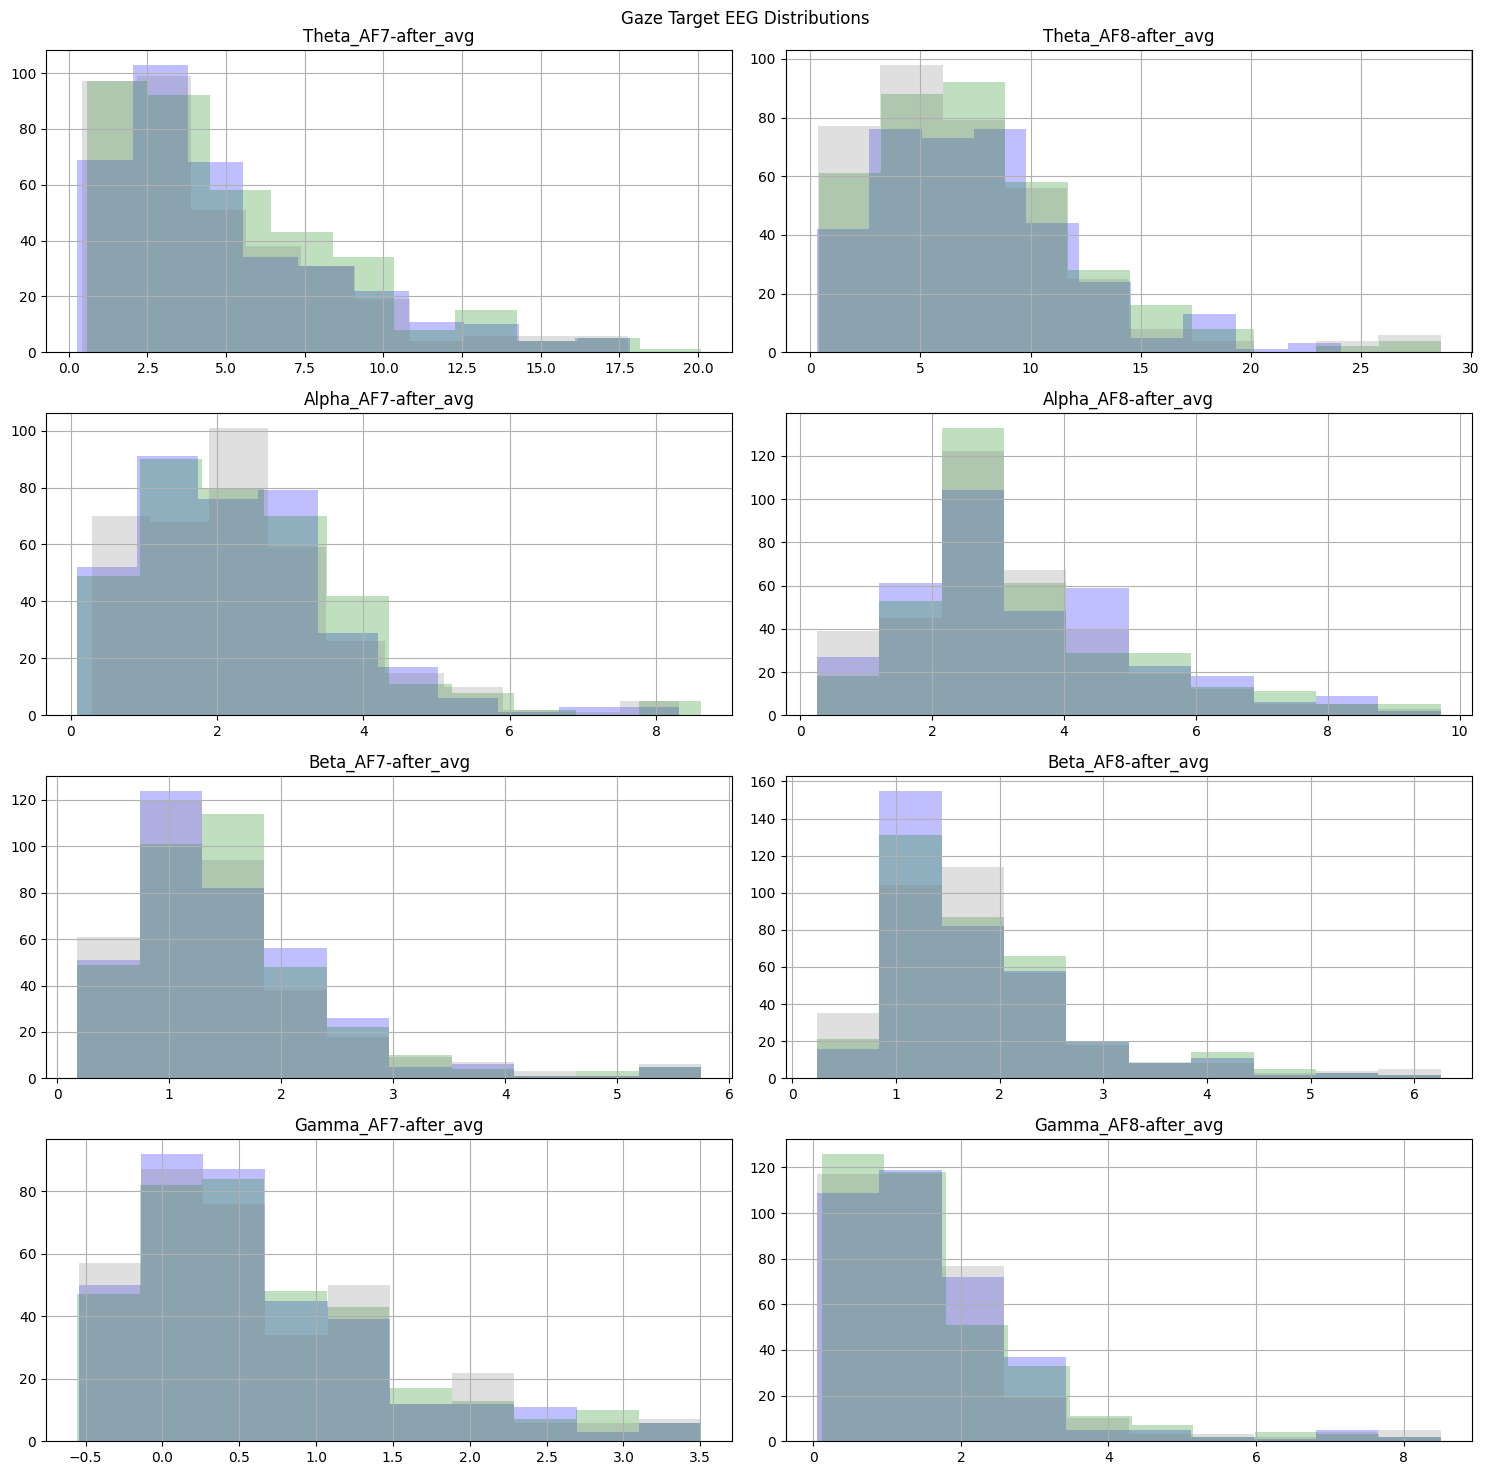

In [86]:
freq_band_colnames = []
for freq in _FREQUENCY_BANDS:
    for electrode in _ELECTRODES:
        freq_band_colnames.append(f'{freq}_{electrode}')

# Calculate EEG avg and max windows prior, during, and after onset of events
applied_gaze_df = gaze_df.apply(lambda row: GetGazeWindowEEGs(row, eeg_df, freq_band_colnames), axis='columns', result_type='expand')
gaze_eeg_df = pd.concat([gaze_df, applied_gaze_df], axis='columns')
gaze_eeg_df.dropna(inplace=True)
display(gaze_eeg_df)

# Let's test for normality via a simple test
for col in freq_band_colnames:
    prior_colname = f"{col}-prior_avg"
    prior_x = gaze_eeg_df[prior_colname]
    prior_res = stats.normaltest(prior_x)
    
    during_colname = f"{col}-during_avg"
    during_x = gaze_eeg_df[during_colname]
    during_res = stats.normaltest(during_x)
    
    after_colname = f"{col}-after_avg"
    after_x = gaze_eeg_df[after_colname]
    after_res = stats.normaltest(after_x)
    
    print(f"{col}: NORMALITY")
    if prior_res.pvalue < 0.05: print("\t*PRIOR:", prior_res)
    else: print("\tPRIOR:", prior_res)
    if during_res.pvalue < 0.05: print("\t*DURING:", during_res)
    else: print("\tDURING:", during_res)
    if after_res.pvalue < 0.05: print("\t*AFTER:", after_res)
    else: print("\tAFTER:", after_res)

# Let's test for normality by putting each band-electrode combo and their variations into a histogram
fig, ax = plt.subplots(nrows=len(_FREQUENCY_BANDS), ncols=len(_ELECTRODES))
fig.set_figheight(15)
fig.set_figwidth(15)
fig.suptitle(f"Gaze Target EEG Distributions")

for i in range(len(_FREQUENCY_BANDS)):
    freq = _FREQUENCY_BANDS[i]
    for j in range(len(_ELECTRODES)):
        electrode = _ELECTRODES[j]
        # prior
        prior_colname = f"{freq}_{electrode}-prior_avg"
        prior_title = f"{freq} {electrode} - Prior Avg"
        gaze_eeg_df.hist(
            column=prior_colname,
            ax=ax[i,j],
            color='blue',
            alpha=0.25
        )
        # during
        during_colname = f"{freq}_{electrode}-during_avg"
        during_title = f"{freq} {electrode} - During Avg"
        gaze_eeg_df.hist(
            column=during_colname,
            ax=ax[i,j],
            color='green',
            alpha=0.25
        )
        # after
        after_colname = f"{freq}_{electrode}-after_avg"
        after_title = f"{freq} {electrode} - After Avg"
        gaze_eeg_df.hist(
            column=after_colname,
            ax=ax[i,j],
            color='gray',
            alpha=0.25
        )
        
plt.tight_layout()
plt.show()

In [87]:
def OneWayAnova_TargetType(df, eeg_column, verbose:bool=True):
    f_stat, p_value = stats.f_oneway(
        df[df['target_type'] == 'VehicleSignal'][eeg_column],
        df[df['target_type'] == 'PedestrianSignal'][eeg_column],
        df[df['target_type'] == 'SignalPole'][eeg_column],
        df[df['target_type'] == 'Vehicle'][eeg_column],
        df[df['target_type'] == 'Pedestrian'][eeg_column],
        df[df['target_type'] == 'Road'][eeg_column],
        df[df['target_type'] == 'Tree'][eeg_column],
        df[df['target_type'] == 'Sidewalk'][eeg_column]
    )
    if verbose:
        if p_value < 0.05:
            print(f'*{eeg_column}','\t f-statistic:',f_stat,'\t p-value:',p_value)
        else:
            print(f'{eeg_column}','\t f-statistic:',f_stat,'\t p-value:',p_value)

def OneWayAnova_TargetState(df, eeg_column, verbose:bool=True):
    f_stat, p_value = stats.f_oneway(
        df[df['target_state'] == 'Static'][eeg_column],
        df[df['target_state'] == 'Dynamic'][eeg_column]
    )
    if verbose:
        if p_value < 0.05:
            print(f'*{eeg_column}','\t f-statistic:',f_stat,'\t p-value:',p_value)
        else:
            print(f'{eeg_column}','\t f-statistic:',f_stat,'\t p-value:',p_value)

In [88]:
print("One Way ANOVA: Target Types\n")
for col in freq_band_colnames:
    OneWayAnova_TargetType(gaze_eeg_df, f'{col}-prior_avg')
    #OneWayAnova_TargetType(gaze_eeg_df, f'{col}-prior_max')
    OneWayAnova_TargetType(gaze_eeg_df, f'{col}-during_avg')
    #OneWayAnova_TargetType(gaze_eeg_df, f'{col}-during_max')
    OneWayAnova_TargetType(gaze_eeg_df, f'{col}-after_avg')
    #OneWayAnova_TargetType(gaze_eeg_df, f'{col}-after_max')
    
print("\nOne Way ANOVA: Target State\n")
for col in freq_band_colnames:
    OneWayAnova_TargetState(gaze_eeg_df, f'{col}-prior_avg')
    #OneWayAnova_TargetState(gaze_eeg_df, f'{col}-prior_max')
    OneWayAnova_TargetState(gaze_eeg_df, f'{col}-during_avg')
    #OneWayAnova_TargetState(gaze_eeg_df, f'{col}-during_max')
    OneWayAnova_TargetState(gaze_eeg_df, f'{col}-after_avg')
    #OneWayAnova_TargetState(gaze_eeg_df, f'{col}-after_max')

One Way ANOVA: Target Types

*Theta_AF7-prior_avg 	 f-statistic: 2.0698064883829224 	 p-value: 0.04614251319499684
*Theta_AF7-during_avg 	 f-statistic: 2.627477413916502 	 p-value: 0.011739100336245267
*Theta_AF7-after_avg 	 f-statistic: 3.054717829193808 	 p-value: 0.003919229482984663
*Theta_AF8-prior_avg 	 f-statistic: 2.337921562809291 	 p-value: 0.024154674262250597
*Theta_AF8-during_avg 	 f-statistic: 4.846594445888156 	 p-value: 3.134015179539753e-05
*Theta_AF8-after_avg 	 f-statistic: 3.2599843203481007 	 p-value: 0.0022891486680011036
Alpha_AF7-prior_avg 	 f-statistic: 1.0803032764567675 	 p-value: 0.37539920144795924
Alpha_AF7-during_avg 	 f-statistic: 0.8143978262058509 	 p-value: 0.5757682450358779
*Alpha_AF7-after_avg 	 f-statistic: 2.5789158451503993 	 p-value: 0.013267820017294521
Alpha_AF8-prior_avg 	 f-statistic: 1.6158562115002908 	 p-value: 0.12967958558684592
*Alpha_AF8-during_avg 	 f-statistic: 2.1684528909263916 	 p-value: 0.03646139407848614
Alpha_AF8-after_avg 	

In [56]:
#'VehicleSignal', 'SignalPole', 'PedestrianSignal', 'Vehicle', 'Pedestrian', 'Road', 'Tree', 'Sidewalk'
#f_stat, p_value = stats.f_oneway(
#    gaze_eeg_df[gaze_eeg_df['target_type'] == 'VehicleSignal']['Theta_AF7-prior_avg'],
#    gaze_eeg_df[gaze_eeg_df['target_type'] == 'PedestrianSignal']['Theta_AF7-prior_avg'],
#    gaze_eeg_df[gaze_eeg_df['target_type'] == 'SignalPole']['Theta_AF7-prior_avg'],
#    gaze_eeg_df[gaze_eeg_df['target_type'] == 'Vehicle']['Theta_AF7-prior_avg'],
#    gaze_eeg_df[gaze_eeg_df['target_type'] == 'Pedestrian']['Theta_AF7-prior_avg'],
#    gaze_eeg_df[gaze_eeg_df['target_type'] == 'Road']['Theta_AF7-prior_avg'],
#    gaze_eeg_df[gaze_eeg_df['target_type'] == 'Tree']['Theta_AF7-prior_avg'],
#    gaze_eeg_df[gaze_eeg_df['target_type'] == 'Sidewalk']['Theta_AF7-prior_avg']
#)
#print(f"F-statistic: {f_stat}, p-value: {p_value}")

F-statistic: 2.069806488382922, p-value: 0.04614251319499684


In [ ]:
# Let's display this participant's EEG data
fig, ax = plt.subplots(nrows=len(_FREQUENCY_BANDS), ncols=len(_ELECTRODES), sharey='row')
fig.set_figheight(15)
fig.set_figwidth(10)
fig.suptitle(f"TRIAL EEG + Crossing Onsets")

for i in range(len(_FREQUENCY_BANDS)):
    color = _FREQUENCY_COLORS[i]
    freq = _FREQUENCY_BANDS[i]
    for j in range(len(_ELECTRODES)):
        electrode = _ELECTRODES[j]
        colname = f"{freq}_{electrode}_normalized"
        title = f"{freq} {electrode} (Normalized)"
        this_ax = eeg_df.plot.line(x='unix_ms',y=colname, ax=ax[i,j], color=color, title=title)
        this_ax.legend_ = None
        for index, row in trial_df.iterrows():
            this_ax.axvline(x=row['start_unix'], color='black')
            this_ax.axvline(x=row['end_unix'], color='gray')
        for index, row in crossing_df.iterrows():
            this_ax.axvspan(row['start_unix_ms'], row['end_unix_ms'], color='lightgray', alpha=0.5)

plt.tight_layout()
plt.show()